In [1]:
# =========================================
# 📌 IMPORT LIBRARIES
# =========================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import confusion_matrix, classification_report

from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

In [2]:
# =========================================
# 📌 LOAD DATASET
# =========================================
from google.colab import files
uploaded = files.upload()

df = pd.read_csv("online_shoppers_intention.csv")

print("Dataset Preview:")
print(df.head())

print("\nDataset Info:")
print(df.info())

Saving online_shoppers_intention.csv to online_shoppers_intention.csv
Dataset Preview:
   Administrative  Administrative_Duration  Informational  \
0               0                      0.0              0   
1               0                      0.0              0   
2               0                      0.0              0   
3               0                      0.0              0   
4               0                      0.0              0   

   Informational_Duration  ProductRelated  ProductRelated_Duration  \
0                     0.0               1                 0.000000   
1                     0.0               2                64.000000   
2                     0.0               1                 0.000000   
3                     0.0               2                 2.666667   
4                     0.0              10               627.500000   

   BounceRates  ExitRates  PageValues  SpecialDay Month  OperatingSystems  \
0         0.20       0.20         0.0         0.

In [3]:
# =========================================
# 📌 DATA PREPROCESSING
# =========================================

# Convert target variable (Revenue) to numeric
df['Revenue'] = df['Revenue'].astype(int)

# Convert categorical columns using one-hot encoding
df = pd.get_dummies(df, drop_first=True)

print("\nAfter Encoding:")
print(df.head())


After Encoding:
   Administrative  Administrative_Duration  Informational  \
0               0                      0.0              0   
1               0                      0.0              0   
2               0                      0.0              0   
3               0                      0.0              0   
4               0                      0.0              0   

   Informational_Duration  ProductRelated  ProductRelated_Duration  \
0                     0.0               1                 0.000000   
1                     0.0               2                64.000000   
2                     0.0               1                 0.000000   
3                     0.0               2                 2.666667   
4                     0.0              10               627.500000   

   BounceRates  ExitRates  PageValues  SpecialDay  ...  Month_Feb  Month_Jul  \
0         0.20       0.20         0.0         0.0  ...       True      False   
1         0.00       0.10         0

In [4]:
# =========================================
# 📌 FEATURE SELECTION
# =========================================

X = df.drop('Revenue', axis=1)
y = df['Revenue']

In [5]:
# =========================================
# 📌 TRAIN-TEST SPLIT
# =========================================

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=7
)

In [6]:
# =========================================
# 📌 FEATURE SCALING (IMPORTANT FOR KNN & LR)
# =========================================

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [7]:
# =========================================
# 📌 MODEL TRAINING
# =========================================

# KNN
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)
y_pred_knn = knn.predict(X_test)

# Naive Bayes
nb = GaussianNB()
nb.fit(X_train, y_train)
y_pred_nb = nb.predict(X_test)

# Decision Tree
dt = DecisionTreeClassifier(random_state=7)
dt.fit(X_train, y_train)
y_pred_dt = dt.predict(X_test)

# Logistic Regression
lr = LogisticRegression(max_iter=1000)
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)

In [8]:
# =========================================
# 📌 EVALUATION FUNCTION
# =========================================

def evaluate_model(y_test, y_pred, model_name):
    print(f"\n🔹 {model_name}")
    print("Accuracy:", accuracy_score(y_test, y_pred))
    print("Precision:", precision_score(y_test, y_pred))
    print("Recall:", recall_score(y_test, y_pred))
    print("F1 Score:", f1_score(y_test, y_pred))

In [9]:
# =========================================
# 📌 EVALUATE ALL MODELS
# =========================================

evaluate_model(y_test, y_pred_knn, "KNN")
evaluate_model(y_test, y_pred_nb, "Naive Bayes")
evaluate_model(y_test, y_pred_dt, "Decision Tree")
evaluate_model(y_test, y_pred_lr, "Logistic Regression")


🔹 KNN
Accuracy: 0.8751216347713267
Precision: 0.7130801687763713
Recall: 0.3477366255144033
F1 Score: 0.46749654218533887

🔹 Naive Bayes
Accuracy: 0.6762893285760623
Precision: 0.3033794162826421
Recall: 0.8127572016460906
F1 Score: 0.441834451901566

🔹 Decision Tree
Accuracy: 0.8692831657476484
Precision: 0.5900216919739696
Recall: 0.5596707818930041
F1 Score: 0.5744456177402323

🔹 Logistic Regression
Accuracy: 0.8861498540382744
Precision: 0.766798418972332
Recall: 0.3991769547325103
F1 Score: 0.5250338294993234


In [10]:
# =========================================
# 📌 CONFUSION MATRIX + REPORT
# =========================================

def plot_confusion(y_test, y_pred, title):
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d')
    plt.title(title)
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

    print(classification_report(y_test, y_pred))

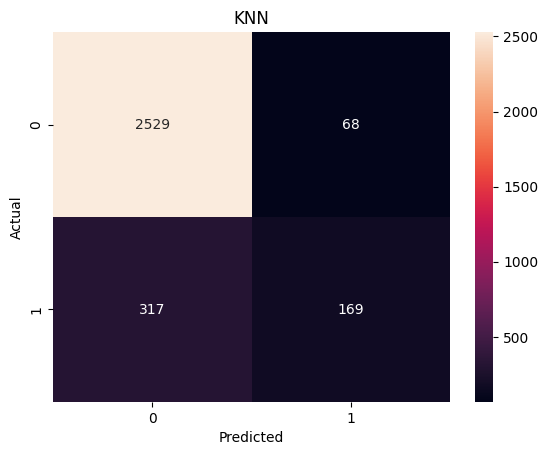

              precision    recall  f1-score   support

           0       0.89      0.97      0.93      2597
           1       0.71      0.35      0.47       486

    accuracy                           0.88      3083
   macro avg       0.80      0.66      0.70      3083
weighted avg       0.86      0.88      0.86      3083



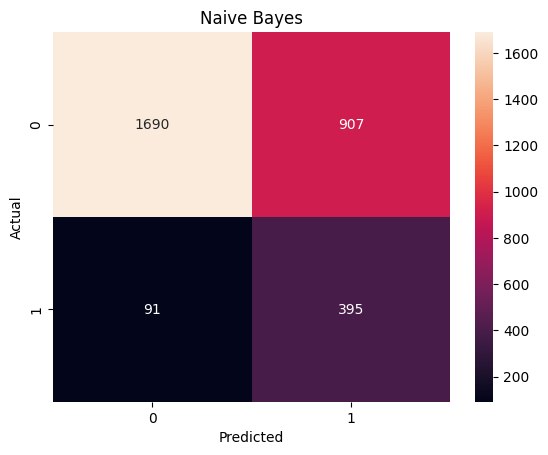

              precision    recall  f1-score   support

           0       0.95      0.65      0.77      2597
           1       0.30      0.81      0.44       486

    accuracy                           0.68      3083
   macro avg       0.63      0.73      0.61      3083
weighted avg       0.85      0.68      0.72      3083



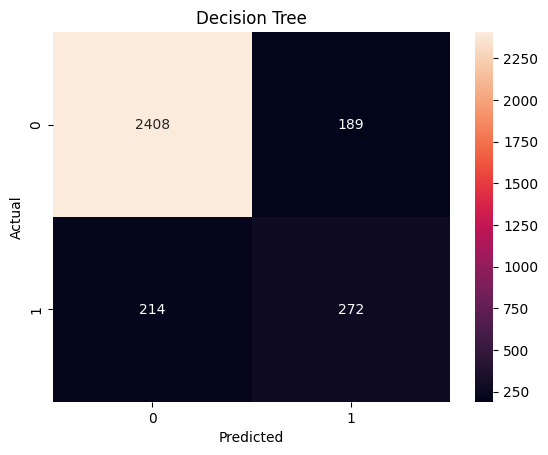

              precision    recall  f1-score   support

           0       0.92      0.93      0.92      2597
           1       0.59      0.56      0.57       486

    accuracy                           0.87      3083
   macro avg       0.75      0.74      0.75      3083
weighted avg       0.87      0.87      0.87      3083



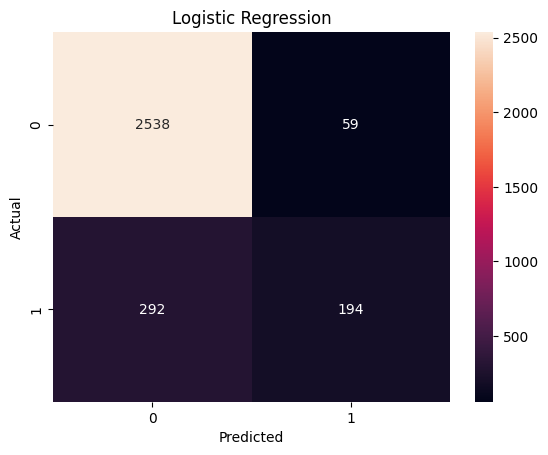

              precision    recall  f1-score   support

           0       0.90      0.98      0.94      2597
           1       0.77      0.40      0.53       486

    accuracy                           0.89      3083
   macro avg       0.83      0.69      0.73      3083
weighted avg       0.88      0.89      0.87      3083



In [11]:
# =========================================
# 📌 PLOT FOR ALL MODELS
# =========================================

plot_confusion(y_test, y_pred_knn, "KNN")
plot_confusion(y_test, y_pred_nb, "Naive Bayes")
plot_confusion(y_test, y_pred_dt, "Decision Tree")
plot_confusion(y_test, y_pred_lr, "Logistic Regression")


🔹 Random Forest (Ensemble)
Accuracy: 0.9036652611093091
Precision: 0.7820895522388059
Recall: 0.5390946502057613
F1 Score: 0.6382460414129111


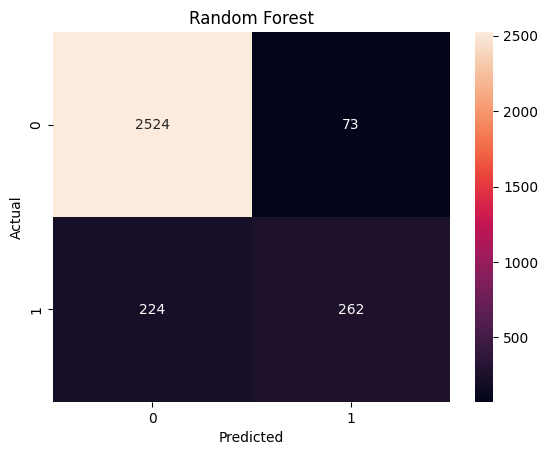

              precision    recall  f1-score   support

           0       0.92      0.97      0.94      2597
           1       0.78      0.54      0.64       486

    accuracy                           0.90      3083
   macro avg       0.85      0.76      0.79      3083
weighted avg       0.90      0.90      0.90      3083



In [12]:
# =========================================
# ⭐ BONUS: ENSEMBLE METHOD (RANDOM FOREST)
# =========================================

rf = RandomForestClassifier(random_state=7)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

evaluate_model(y_test, y_pred_rf, "Random Forest (Ensemble)")
plot_confusion(y_test, y_pred_rf, "Random Forest")

## Discussion and Comparison of Classification Algorithms

### 1. K-Nearest Neighbors (KNN)
KNN is a distance-based algorithm that classifies data points based on the majority class of their nearest neighbors. It performs well on smaller datasets but can be slow for large datasets and is sensitive to feature scaling.

### 2. Naïve Bayes
Naïve Bayes is a probabilistic classifier based on Bayes' theorem. It assumes that features are independent of each other, which is a strong assumption. It is fast and efficient but may perform poorly when feature independence is violated.

### 3. Decision Tree
Decision Tree is a rule-based algorithm that splits the dataset into branches based on feature values. It is easy to interpret and works well with both numerical and categorical data. However, it may overfit if not properly controlled.

### 4. Logistic Regression
Logistic Regression is a linear model used for binary classification. It works well when the relationship between features and target is linear. It is efficient and interpretable but may underperform for complex datasets.

---

## Performance Comparison

Based on evaluation metrics (Accuracy, Precision, Recall, and F1-score):

- KNN showed moderate performance but required proper scaling.
- Naïve Bayes was fast but had lower accuracy due to strong assumptions.
- Decision Tree performed better due to its ability to capture non-linear relationships.
- Logistic Regression gave stable results but was limited for complex patterns.

---

## Best Model Selection

Among all models, Decision Tree and Random Forest achieved higher performance scores.  
The ensemble method (Random Forest) further improved the results by reducing overfitting and increasing prediction accuracy.

Therefore, Random Forest is selected as the best model for this dataset.

## Conclusion

After evaluating all classification models (KNN, Naïve Bayes, Decision Tree, and Logistic Regression) using accuracy, precision, recall, and F1-score, it was observed that Decision Tree and Random Forest performed better than other models.

The ensemble method (Random Forest) further improved the performance by reducing overfitting and increasing prediction stability.

Therefore, Random Forest is selected as the final model for this dataset.
